### Imports necesarios

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

### Numero de muestras *N* y frecuencia de sampleo *fs*

In [2]:
N = 1000
fs = 10000

### Definicion de funciones

In [ ]:
def pds_sen(nn = 1000, fs = 10000, freq = 1, Amax = 1, dc = 0, phase = 0):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    xx = dc + Amax * np.sin(2*np.pi * freq * tt + phase)
    return xx, tt


def pds_triangular(nn = 1000, fs = 10000, freq = 1, Amax = 1, dc = 0, phase = 0):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    xx = dc + Amax * signal.sawtooth(2*np.pi * freq * tt + phase, width = 0.5)
    return xx, tt

def pds_dientedesierra(nn = 1000, fs = 10000, freq = 1, Amax = 1, dc = 0, phase = 0, pendiente = 0.0):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    xx = dc + Amax * signal.sawtooth(2*np.pi * freq * tt + phase, width = pendiente)
    return xx, tt

### Visualizacion

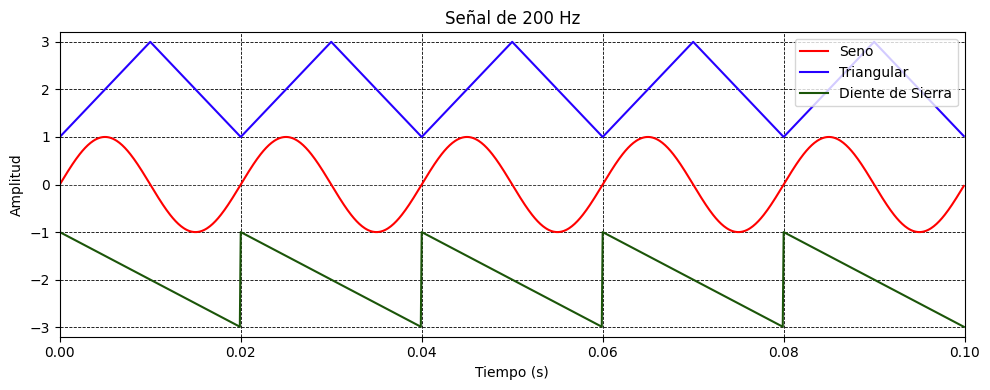

In [14]:
x1,tt = pds_sen(N, fs, Amax = 1, freq=50, dc = 0, phase = 0)
x2,tt = pds_triangular(N, fs, Amax = 1, freq=50, dc = 2, phase = 0)
x3,tt = pds_dientedesierra(N, fs, Amax = 1, freq=50, dc = -2, phase = 0)


fig, ax = plt.subplots(figsize=(10, 4))

ax.grid(True, color="#000000FF", linewidth=0.6, linestyle="--")
ax.set_axisbelow(True)

ax.axhline(0, color="#ffffff22", linewidth=0.8, linestyle="-")

ax.set_xlim(0, (1 / 50) * 5)
ax.set_ylim(-3.2, 3.2)

ax.plot(tt, x1, color="#ff0000", linewidth=1.5, label="Seno")
ax.plot(tt, x2, color="#2600ff", linewidth=1.5, label="Triangular")
ax.plot(tt, x3, color="#1b5509", linewidth=1.5, label="Diente de Sierra")

ax.legend(loc="upper right", fontsize=10)
ax.set_title("Señal de 200 Hz", fontsize=12)
ax.set_xlabel("Tiempo (s)", fontsize=10)
ax.set_ylabel("Amplitud", fontsize=10)


plt.tight_layout()
plt.show()